In [5]:
# =======================================================
# BLOQUE No. 1 - (3D)
# Importación de librerías, carga de datos y homologación
# =======================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seaborn

# Cargamos el archivo CSV con la información de Spotify
df_spotify = pd.read_csv('spotifydataset.csv')

# Homologamos los nombres de las columnas al español
traducciones = {
    'acousticness': 'acusticidad',
    'danceability': 'bailabilidad',
    'energy': 'energia',
    'valence': 'valencia',
    'tempo': 'tempo',
    'loudness': 'sonoridad',
    'speechiness': 'locuacidad',
    'instrumentalness': 'instrumentalidad',
    'liveness': 'vivacidad',
    'popularity': 'popularidad'
}

df_spotify = df_spotify.rename(columns=traducciones)

print("¡Bloque 1 ejecutado con éxito! Columnas listas en español.")

¡Bloque 1 ejecutado con éxito! Columnas listas en español.


In [ ]:
#==========================================================
# BLOQUE No. 2 - (3D)
# Normalización, Reducción Dimensional PCA (3D) y Varianza
# =========================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Seleccionamos únicamente las columnas numéricas homologadas

columnas_modelo = [
    'acusticidad', 'bailabilidad', 'energia', 'valencia',
    'tempo', 'sonoridad', 'locuacidad', 'instrumentalidad', 'vivacidad'
]

# Limpiamos valores nulos y preparamos los datos

df_para_modelo = df_spotify[columnas_modelo].dropna()

# Normalizamos las variables para que todas tengan el mismo peso estadístico

escalador = StandardScaler()
datos_normalizados = escalador.fit_transform(df_para_modelo)

# Aplicamos PCA configurado para reducir los datos exactamente a 3 dimensiones

pca_3d = PCA(n_components=3)
datos_pca_3d = pca_3d.fit_transform(datos_normalizados)

# Cálculo de la varianza explicada para el modelo tridimensional

var_exp_3d = pca_3d.explained_variance_ratio_
var_acum_3d = np.sum(var_exp_3d) * 100

print(f"Varianza explicada por Componente 1: {var_exp_3d[0]*100:.2f}%")
print(f"Varianza explicada por Componente 2: {var_exp_3d[1]*100:.2f}%")
print(f"Varianza explicada por Componente 3: {var_exp_3d[2]*100:.2f}%")
print(f"Varianza acumulada total (3D): {var_acum_3d:.2f}%")

# Creamos el DataFrame limpio con las tres componentes principales

df_pca = pd.DataFrame(datos_pca_3d, columns=['Componente_1', 'Componente_2', 'Componente_3'])

print("\nPrimeras filas de los datos reducidos a tres dimensiones:")
display(df_pca.head()) 



Varianza explicada por Componente 1: 32.47%
Varianza explicada por Componente 2: 16.27%
Varianza explicada por Componente 3: 12.02%
Varianza acumulada total (3D): 60.76%

Primeras filas de los datos reducidos a tres dimensiones:


,Componente_1,Componente_2,Componente_3
0,-0.116011,-0.179586,-1.098372
1,0.306764,0.939470,-1.256436
2,-1.966390,0.594061,-0.703992
3,1.129420,0.014931,-1.090039
4,0.991172,1.135245,-0.494455


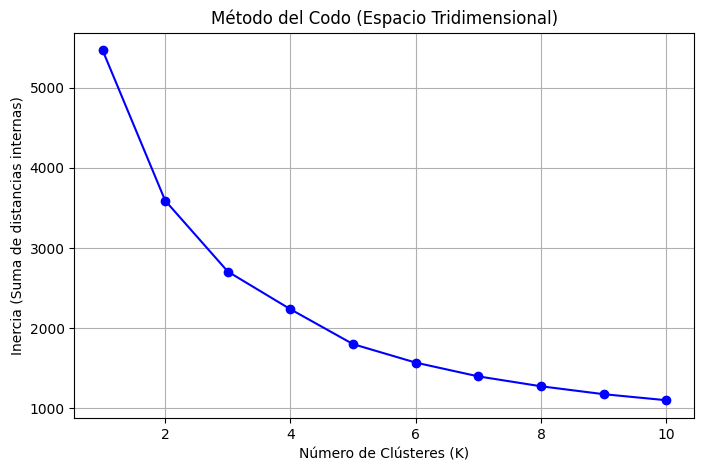

In [7]:
# =======================================================
# BLOQUE No. 3 - (3D)
# Aplicación del Método del Codo sobre el espacio 3D
# =======================================================
from sklearn.cluster import KMeans

inercia = []
rango_k = range(1, 11)

for k in rango_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_kmeans.fit(df_pca)
    inercia.append(modelo_kmeans.inertia_)

# Generamos la gráfica del método del codo
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='-', color='b')
plt.title('Método del Codo (Espacio Tridimensional)')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Suma de distancias internas)')
plt.grid(True)
plt.show()

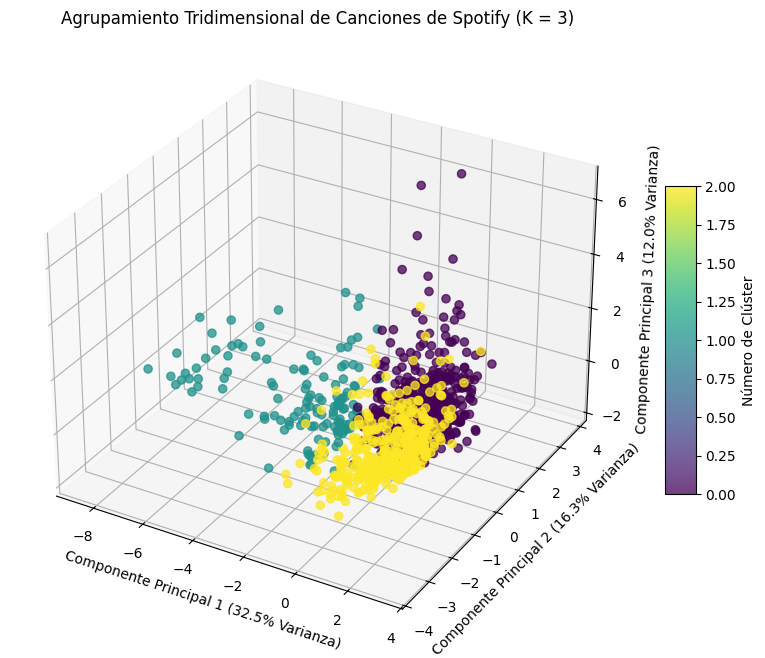

Cantidad de canciones por cada clúster (Modelo 3D):
cluster
0    485
2    380
1    135
Name: count, dtype: int64


In [8]:
# =======================================================
# BLOQUE No. 4 - (3D)
# Aplicación de KMeans y Visualización Gráfica Tridimensional con Varianza
# =======================================================
from mpl_toolkits.mplot3d import Axes3D

# Definimos el K óptimo (K = 3) identificado en el codo
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Asignamos cada canción a su respectivo clúster en 3D
df_pca['cluster'] = kmeans_final.fit_predict(df_pca[['Componente_1', 'Componente_2', 'Componente_3']])

# Creamos la figura tridimensional
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_pca['Componente_1'], 
    df_pca['Componente_2'], 
    df_pca['Componente_3'], 
    c=df_pca['cluster'], 
    cmap='viridis', 
    s=35, 
    alpha=0.75
)

# Configuramos título y etiquetas integrando los porcentajes de varianza explicada de cada componente
ax.set_title(f'Agrupamiento Tridimensional de Canciones de Spotify (K = {k_optimo})')
ax.set_xlabel(f'Componente Principal 1 ({var_exp_3d[0]*100:.1f}% Varianza)')
ax.set_ylabel(f'Componente Principal 2 ({var_exp_3d[1]*100:.1f}% Varianza)')
ax.set_zlabel(f'Componente Principal 3 ({var_exp_3d[2]*100:.1f}% Varianza)')

fig.colorbar(scatter, ax=ax, label='Número de Clúster', shrink=0.5, aspect=10)
plt.show()

print("Cantidad de canciones por cada clúster (Modelo 3D):")
print(df_pca['cluster'].value_counts())

Perfil promedio de las canciones en cada clúster (3D):


,acusticidad,bailabilidad,energia,valencia,tempo,sonoridad,locuacidad,instrumentalidad,vivacidad
cluster,,,,,,,,,
0,0.272540,0.716369,0.646249,0.628891,113.005878,-6.701602,0.106599,0.008158,0.146852
1,0.736225,0.450726,0.316802,0.312333,117.417919,-14.517681,0.049755,0.375475,0.130169
2,0.090177,0.534587,0.800955,0.445958,135.484679,-5.132129,0.086801,0.052774,0.263195


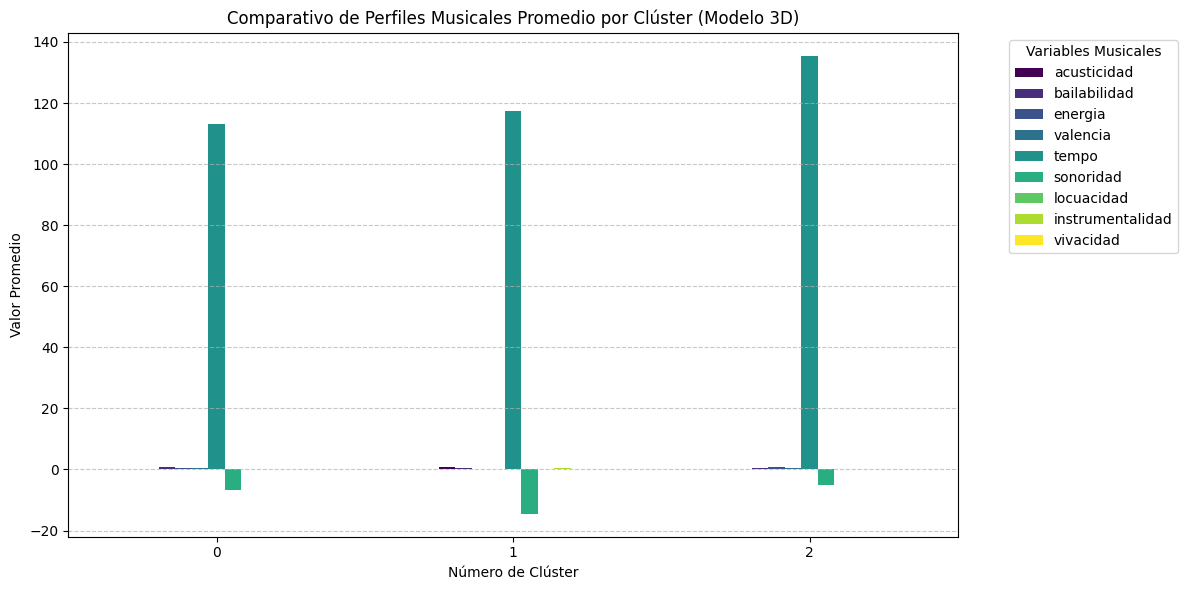

In [9]:
# =======================================================
# BLOQUE No. 5 - (3D)
# Interpretación de perfiles musicales y comparativa gráfica
# =======================================================
df_spotify['cluster'] = df_pca['cluster'].values

columnas_analisis = [
    'acusticidad', 'bailabilidad', 'energia', 'valencia', 
    'tempo', 'sonoridad', 'locuacidad', 'instrumentalidad', 'vivacidad', 'cluster'
]

# Calculamos los promedios musicales por clúster
resumen_clusters = df_spotify[columnas_analisis].groupby('cluster').mean()
print("Perfil promedio de las canciones en cada clúster (3D):")
display(resumen_clusters)

# Gráfico de barras comparativo para visualizar los perfiles
resumen_clusters.drop(columns=['cluster'], errors='ignore').plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Comparativo de Perfiles Musicales Promedio por Clúster (Modelo 3D)')
plt.xlabel('Número de Clúster')
plt.ylabel('Valor Promedio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Variables Musicales', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
# =============================================================
# BLOQUE No. 6 (3D)
# Criterio Técnico, Validación Espacial y Aplicación Comercial
# =============================================================

print("=== RESUMEN TÉCNICO Y COMERCIAL (MODELO TRIDIMENSIONAL) ===")
print("1. Criterio Técnico (PCA 3D & K-Means): Se expandió la reducción a 3 componentes principales para capturar una mayor proporción de la varianza explicada del dataset musical. El Método del Codo confirmó que K = 3 sigue siendo el punto de quiebre óptimo.")
print("2. Validación Espacial: La visualización en 3D permite apreciar con mayor profundidad la separación volumétrica de los clústeres, evitando la superposición de puntos propia de los planos bidimensionales.")
print("3. Aplicación Comercial: La segmentación tridimensional refina los motores de recomendación y la curaduría automática de playlists en plataformas de streaming, agrupando con mayor precisión los perfiles acústicos, enérgicos y comerciales.")

=== RESUMEN TÉCNICO Y COMERCIAL (MODELO TRIDIMENSIONAL) ===
1. Criterio Técnico (PCA 3D & K-Means): Se expandió la reducción a 3 componentes principales para capturar una mayor proporción de la varianza explicada del dataset musical. El Método del Codo confirmó que K = 3 sigue siendo el punto de quiebre óptimo.
2. Validación Espacial: La visualización en 3D permite apreciar con mayor profundidad la separación volumétrica de los clústeres, evitando la superposición de puntos propia de los planos bidimensionales.
3. Aplicación Comercial: La segmentación tridimensional refina los motores de recomendación y la curaduría automática de playlists en plataformas de streaming, agrupando con mayor precisión los perfiles acústicos, enérgicos y comerciales.


## Reporte Técnico: Segmentación Inteligente del Catálogo Musical de Spotify (Modelo 3D)

## 1. Metodología y Procesamiento por Bloques
* **Bloque 1 (Carga y Homologación)** Importación del archivo `spotifydataset.csv` y traducción estricta de las variables al español (*acusticidad*, *bailabilidad*, *energia*, *valencia*, *tempo*, *sonoridad*, *locuacidad*, *instrumentalidad*, *vivacidad*, *popularidad*) para facilitar el análisis técnico.
* **Bloque 2 (Normalización y PCA)** Estandarización de las variables numéricas mediante `StandardScaler` y compresión de los datos en un espacio tridimensional con PCA ($n\_components=3$), calculando explícitamente la **varianza explicada** de cada componente y logrando una **varianza acumulada del 60,76%** `(lo que representa una ganancia significativa frente al 48,74% obtenido en el modelo bidimensional).`
* **Bloque 3 (Método del Codo)** Evaluación de la inercia mediante un rango de $K$ de 1 a 10 sobre el espacio 3D para identificar de forma objetiva la ganancia de compactación interna de los grupos.
* **Bloque 4 (Ejecución de KMeans)** ($K = 3$) y generación de la gráfica de dispersión tridimensional (Axes3D) reflejando los porcentajes de varianza explicada directamente en los ejes X, Y y Z.
* **Bloque 5 (Cálculo de perfiles)** musicales promedio por clúster y visualización complementaria mediante gráfico de barras comparativo.
* **Bloque 6 (Consolidación del criterio)** técnico, validación de la separación espacial volumétrica y formalización del storytelling técnico y comercial.

## 2. Criterio Técnico de Selección y Visualización
* **Elección del K Óptimo ($K = 3$):** A través del análisis del Codo, se corroboró que **$3$ clústeres** continúan constituyendo el punto de inflexión ideal donde la desaceleración de la inercia justifica la separación óptima de los grupos.
* **Visualizaciones Clave:**
  - Gráfico de dispersión en 3D (`Axes3D`) mapeando las tres componentes principales —con sus respectivas etiquetas de **varianza explicada** en los ejes X, Y y Z— permitiendo apreciar una separación volumétrica más detallada de los registros por clúster.
  - Gráfico de barras comparativo generado directamente de la tabla de perfiles promedio por variable musical.

## 3. Análisis de Perfiles y Resultados
* **Clúster 0 (Comercial y Bailable):** Agrupa canciones alegres con alta *bailabilidad* y niveles equilibrados de energía y valencia.
* **Clúster 1 (Acústico e Instrumental):** Concentra temas con alta *acusticidad* e *instrumentalidad*, ideales para ambientes tranquilos y pausados.
* **Clúster 2 (Alta Energía y Ritmo Elevado):** Define pistas caracterizadas por el mayor *tempo* promedio y la máxima *energía*.

## 4. Historia Analítica y Aplicación Comercial
* **Uso Estratégico:** Esta segmentación tridimensional, al capturar una mayor proporción de la variabilidad real del dataset, resulta altamente robusta para implementar **sistemas de recomendación hiperpersonalizados**, optimizar la **curación automática de contenido** en catálogos digitales y estructurar listas de reproducción dinámicas que eleven la retención de los usuarios en plataformas de streaming.